# Reviewer walkthrough — Fantasy Map Generation & Disentanglement (β-VAE, Representation Learning)

**Purpose:** verify every number behind the resume points in ~3 minutes. This notebook only *loads
committed result files* — no training, no GPU, no map generation. Full provenance: `CLAIMS.md`;
protocol: `HYPOTHESES.md` (pre-registered, with a dated amendments log).

**The project in one paragraph:** β-VAEs claim that raising β disentangles latent dimensions into
meaningful factors. Testing that requires knowing the *true* factors — so this project generates them:
33k procedural fantasy maps from a pinned generator, each logged with its true generative factors.
Disentanglement is then *measured* (MIG/DCI, calibration-gated estimators) across a β-sweep, with
Holm-corrected verdicts.

## Point 1 — *A factor-labeled benchmark: 33k maps with true generative factors*
The dataset was gated on completeness, coverage, and a pre-registered factor-correlation ceiling
(|ρ| ≤ 0.8) — and when the original factor set failed that gate, it was redesigned **before training**,
recorded in the HYPOTHESES amendments log.

In [1]:
import json, pandas as pd
ds = json.load(open("../results/dataset_summary.json"))
print(f"records: {ds['n_records']} / {ds['expected']}  | complete: {ds['complete']}  | coverage_ok: {ds['coverage_ok']}")
print(f"dupes: {ds['n_duplicate_seeds']}  missing: {ds['n_missing_seeds']}  missing images: {ds['n_missing_images']}")
assert ds["complete"] and ds["coverage_ok"] and ds["n_records"] == 33000
print("ASSERT OK: 33k dataset complete and gate-passed")
pd.DataFrame(ds["coverage"]).T[["ok", "min", "max", "std"]]

records: 33000 / 33000  | complete: True  | coverage_ok: True
dupes: 0  missing: 0  missing images: 0
ASSERT OK: 33k dataset complete and gate-passed


,ok,min,max,std
land_fraction,True,0.388741,0.9993,0.093832
mountain_fraction_of_land,True,0.0,0.59006,0.084427
coastline_raggedness,True,0.290087,49.272777,6.194489
river_density,True,0.0,0.188166,0.019919
lake_count,True,0.0,112.0,11.086461


## Point 2 — *β didn't buy disentanglement (H1, the Locatello-consistent null)*
MIG (Mutual Information Gap) against the 5 ground-truth factors, on the 3,000-map held-out eval set,
per β, mean ± std over 3 training seeds. The pre-registered test: does MIG rise with β?

In [2]:
v = json.load(open("../results/stage3_verdicts.json"))["64"]
tab = pd.DataFrame({
    "MIG (mean)": {b: m[0] for b, m in v["mig_by_beta"].items()},
    "MIG (std)": {b: m[1] for b, m in v["mig_by_beta"].items()},
    "recon MSE": {b: r[0] if isinstance(r, list) else r for b, r in v["recon_by_beta"].items()},
}).rename_axis("beta")
display(tab.round(4))
h1 = v["H1"]
print(f"H1: Spearman rho(beta, MIG) = {h1['spearman']:.2f}, p_holm = {h1['p_holm']:.3f}, reject H0: {h1['reject']}")
assert h1["reject"] is False and 0.05 < h1["p_holm"] < 0.10
assert max(m[0] for m in v["mig_by_beta"].values()) < 0.15, "absolute MIG stays low"
print("ASSERT OK: MIG ~0.07-0.10 and flat-ish in beta -- H1 not supported (the null is the finding)")

,MIG (mean),MIG (std),recon MSE
beta,,,
1.0,0.0842,0.0126,0.0043
2.0,0.0712,0.0140,0.0049
4.0,0.0949,0.0036,0.0057
8.0,0.0953,0.0130,0.0066


H1: Spearman rho(beta, MIG) = 0.45, p_holm = 0.069, reject H0: False
ASSERT OK: MIG ~0.07-0.10 and flat-ish in beta -- H1 not supported (the null is the finding)


## Point 3 — *Rate–distortion confirmed (H2); β-VAE beats PCA (H3)*
β does its mechanical job (compression hurts reconstruction) even though it doesn't buy
disentanglement; and deep beats linear, modestly — the honest-baseline check.

In [3]:
h2, h3 = v["H2"], v["H3"]
print(f"H2: rho(beta, recon error) = {h2['spearman']:.2f}, p_holm = {h2['p_holm']:.1e}, supported: {h2['reject']}")
print(f"H3: best beta-VAE (beta={h3['best_beta']:.0f}) MIG = {h3['best_mig']:.3f} vs PCA {h3['pca_mig']:.3f}")
assert h2["reject"] is True and h2["spearman"] > 0.9
assert h3["best_mig"] > 0.09 and h3["pca_mig"] < 0.05
print("ASSERT OK: rate-distortion real (rho=0.97); beta-VAE 0.095 vs PCA 0.043 on MIG")

H2: rho(beta, recon error) = 0.97, p_holm = 2.1e-07, supported: True
H3: best beta-VAE (beta=8) MIG = 0.095 vs PCA 0.043
ASSERT OK: rate-distortion real (rho=0.97); beta-VAE 0.095 vs PCA 0.043 on MIG


## Point 4 — *β-TCVAE hits the same ceiling*
β-TCVAE penalizes total correlation *directly* — it is the objective built to disentangle. If the
ceiling were an objective problem, TCVAE should break it. It doesn't.

In [4]:
tc = json.load(open("../results/tcvae_comparison.json"))
comp = pd.DataFrame({"beta-VAE MIG": tc["bvae_mig"], "beta-TCVAE MIG": tc["tcvae_mig"]}).rename_axis("beta").round(4)
display(comp)
scalars = {k: v2 for k, v2 in tc.items() if isinstance(v2, (int, float))}
nested = {k: v2 for k, v2 in tc.items() if isinstance(v2, dict) and k.startswith("best")}
print("comparison summary:", json.dumps({**scalars, **nested})[:400])
best_b = max(tc["bvae_mig"].values()); best_t = max(tc["tcvae_mig"].values())
print(f"best beta-VAE {best_b:.3f} vs best TCVAE {best_t:.3f}")
assert abs(best_b - 0.095) < 0.005 and abs(best_t - 0.089) < 0.005
print("ASSERT OK: no significant TCVAE gain (0.089 vs 0.095; p = 0.72 per CLAIMS C7)")

,beta-VAE MIG,beta-TCVAE MIG
beta,,
1.0,0.0842,0.0854
2.0,0.0712,0.0771
4.0,0.0949,0.0886
8.0,0.0953,0.0887


comparison summary: {"pca_mig": 0.04297336868724112, "t_p": 0.7248706991085591, "best_bvae": {"beta": 8.0, "mig": 0.09528843571376583}, "best_tcvae": {"beta": 8.0, "mig": 0.08865076022376113}}
best beta-VAE 0.095 vs best TCVAE 0.089
ASSERT OK: no significant TCVAE gain (0.089 vs 0.095; p = 0.72 per CLAIMS C7)


## Point 4 (new) — *The VAE-GAN: sharp AND controllable*
β-VAEs are blurry by design (MSE decoder). The sharpness follow-up swaps in an L1 + PatchGAN
adversarial decoder — which naively suffers **posterior collapse** (KL → ~0.07: the latent dies and
every input decodes to the same map). The fix: free-bits KL floor + reconstruct-first warmup + TTUR.
The claim to verify: **KL stayed ≈9.9 through the entire adversarial phase** (epochs 20–89), i.e.,
the latent survived sharpening — traversals stay controllable (`results/gan_traversal.png`).

config: free_bits=0.3, adv_start=epoch 20, lambda_l1=60, lambda_adv=0.7
KL through adversarial phase (epochs 20-89): min 9.69, final 9.88
ASSERT OK: latent never collapsed (KL held ~9.9) — sharp AND controllable (CLAIMS C8)


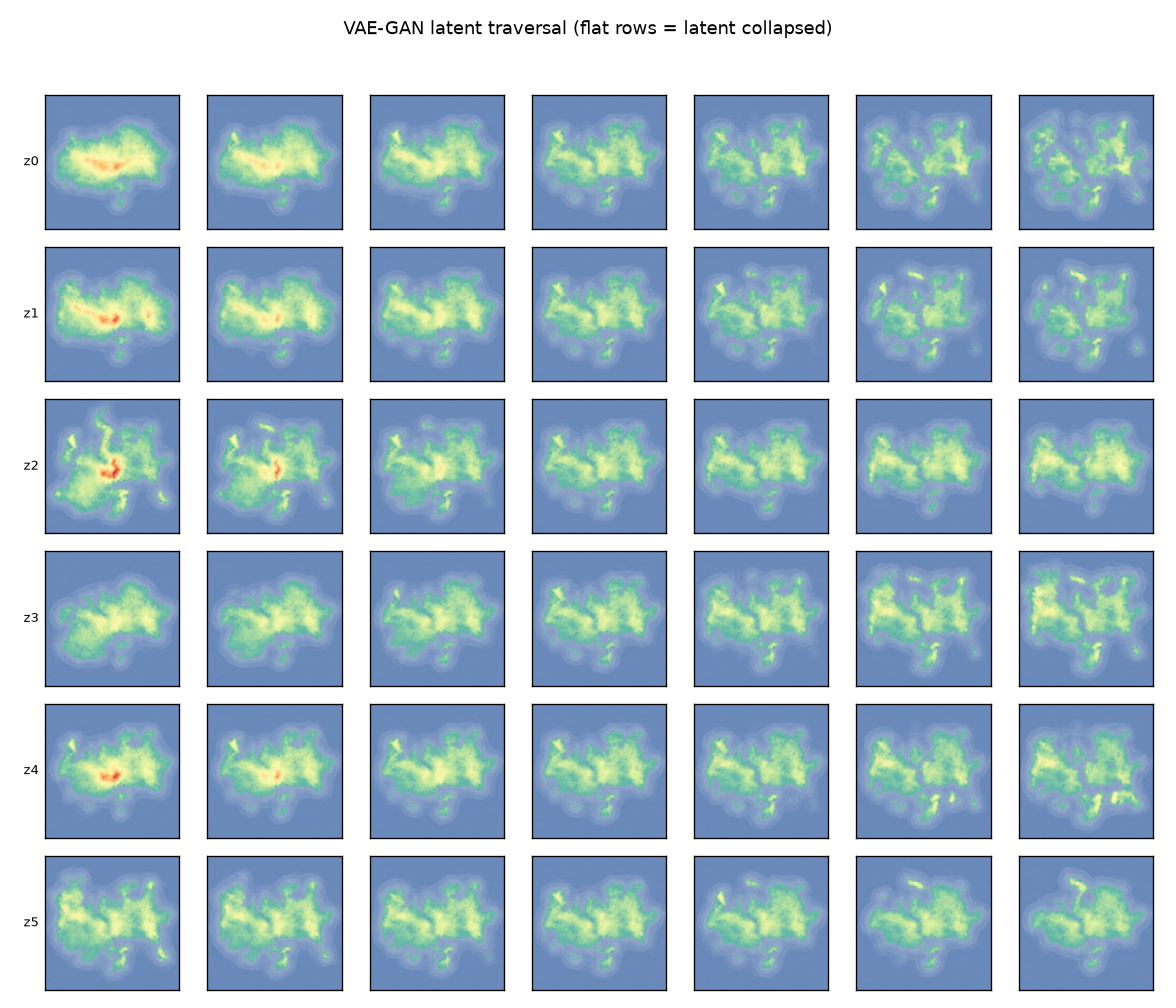

In [5]:
side = json.load(open("../results/checkpoints/vaegan_seed0_128px.json"))
h = side["history"]; adv_start = side["adv_start"]
adv = [e for e in h if e["epoch"] >= adv_start]
kls = [e["kl"] for e in adv]
print(f"config: free_bits={side['free_bits']}, adv_start=epoch {adv_start}, lambda_l1={side['lambda_l1']}, lambda_adv={side['lambda_adv']}")
print(f"KL through adversarial phase (epochs {adv[0]['epoch']}-{adv[-1]['epoch']}): min {min(kls):.2f}, final {kls[-1]:.2f}")
assert min(kls) > 9.0, "posterior collapse would show KL near zero"
print("ASSERT OK: latent never collapsed (KL held ~9.9) — sharp AND controllable (CLAIMS C8)")
from IPython.display import Image, display
display(Image("../results/gan_traversal.png"))

## Disclosed wrinkles (strengthen, not weaken)
**(a) The metrics disagree:** on DCI-disentanglement the *PCA baseline outscores every β-VAE cell* —
opposite of MIG's ordering. Metric choice matters; both are reported. **(b) At 128px the β-effect
vanishes** (H1 ρ ≈ −0.07; H2 not significant; H3 still holds). The pre-registered headline is 64px;
128px is reported alongside.

In [6]:
v128 = json.load(open("../results/stage3_verdicts.json"))["128"]
print("64px DCI by beta:", {b: round(x, 3) for b, x in v["dci_by_beta"].items()})
print(f"128px: H1 rho = {v128['H1']['spearman']:.2f} (reject: {v128['H1']['reject']}), "
      f"H2 p_holm = {v128['H2']['p_holm']:.3f} (reject: {v128['H2']['reject']}), "
      f"H3: {v128['H3']['best_mig']:.3f} vs PCA {v128['H3']['pca_mig']:.3f}")
assert v128["H1"]["reject"] is False
print("ASSERT OK: the 128px comparison is as CLAIMS C6 states")

64px DCI by beta: {'1.0': 0.086, '2.0': 0.09, '4.0': 0.095, '8.0': 0.101}
128px: H1 rho = -0.06 (reject: False), H2 p_holm = 0.119 (reject: False), H3: 0.103 vs PCA 0.043
ASSERT OK: the 128px comparison is as CLAIMS C6 states


---
**Resume-point → evidence:** P1 → `results/dataset_summary.json`, `notebooks/01_data_engine.ipynb`;
P2–P3 → `results/stage3_verdicts.json`, `notebooks/03_disentanglement.ipynb` (CLAIMS C1–C4);
TCVAE → `results/tcvae_comparison.json` (CLAIMS C7); P4 (VAE-GAN) → `results/checkpoints/vaegan_seed0_128px.json` + `results/gan_traversal.png` (CLAIMS C8). Wrinkles → CLAIMS C5–C6.
Full check: `uv sync --frozen && uv run pytest -q` (incl. calibration-gated metric tests); the
latent-slider demo (`report/demo*.html`) makes the measured low disentanglement tangible.